#EXPLICIT RECOMMENDATION SYSTEM - RATING

##Set up

###Connect drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Install library

In [ ]:
!pip install "numpy<2"

In [ ]:
!pip install scikit-surprise

In [ ]:
!pip install tqdm

###import thư viện

In [ ]:
# Các thư viện hệ thống và công cụ
import os
import gc
import joblib
import json
import math
import time
import pickle
import psutil
import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt
from collections import defaultdict
from joblib import Parallel, delayed

# Các thư viện toán học và xử lý dữ liệu
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import coo_matrix, csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold, GridSearchCV

# Thư viện tiến trình
from tqdm.notebook import tqdm

###Path of data

In [ ]:
# Set the path
data_path = '/content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/data/'
save_path = '/content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/'

# Global performance dictionary
GLOBAL_METRICS = {}

##Content-Base Filtering (CBF)

###Content-Based Model

In [ ]:
class ContentBasedModel:
    def __init__(self, data_path, folder, file_name, max_features=500, alphas=None, batch_size=None):
        self.data_path = data_path
        self.folder = folder
        self.file_name = file_name
        self.max_features = max_features
        self.alphas = alphas if alphas is not None else [0.01]
        self.batch_size = batch_size

        self.W = None
        self.b = None
        self.X = None
        self.tfidf = None
        self.items = None
        self.X_content = None

        self.n_users = 0
        self.n_items = 0
        self.alpha_rmse_list = []
        self.best_alpha = None

    def load_data(self):
        print(f"\n🔹 Loading data for: {self.file_name}")
        train_path = os.path.join(self.data_path, self.folder, self.file_name + ".train.rating")
        test_path = os.path.join(self.data_path, self.folder, self.file_name + ".test.rating")
        meta_path = os.path.join(self.data_path, self.folder, self.file_name + ".id.meta.json")

        self.ratings_train = pd.read_csv(train_path, sep="\t", header=None)
        self.ratings_test = pd.read_csv(test_path, sep="\t", header=None)
        self.items = pd.read_json(meta_path, lines=True)

        self.rate_train = self.ratings_train.to_numpy()
        self.rate_test = self.ratings_test.to_numpy()

        self.n_users = self.ratings_train[0].nunique()
        self.n_items = self.items.shape[0]

        i_cols = ['item_id', 'main_category', 'categories', 'title', 'store', 'description', 'features', 'average_rating', 'rating_number']
        self.items = self.items[i_cols]

    def preprocess_items(self):
        print("\n🔹 Preprocessing item metadata...")
        cols_to_concat = ['title', 'description', 'main_category', 'features', 'store', 'categories']
        self.items[cols_to_concat] = self.items[cols_to_concat].fillna("")

        for col in cols_to_concat:
            self.items[col] = self.items[col].apply(lambda x: " ".join(map(str, x)) if isinstance(x, list) else str(x))

        self.X_content = (
            self.items['title'] + " " +
            self.items['description'] + " " +
            self.items['main_category'] + " " +
            self.items['features'] + " " +
            self.items['store'] + " " +
            self.items['categories']
        )

    def vectorize(self):
        print("\n🔹 Vectorizing using TF-IDF...")
        self.tfidf = TfidfVectorizer(stop_words='english', max_features=self.max_features)
        self.X = self.tfidf.fit_transform(self.X_content)
        self.X = normalize(self.X, norm='l2')

    def get_items_rated_by_user(self, rate_matrix, user_id):
        user_ids = rate_matrix[:, 0]
        ids = np.where(user_ids == user_id)[0]
        item_ids = rate_matrix[ids, 1].astype(int)
        scores = rate_matrix[ids, 2].astype(float)
        return item_ids, scores

    def train_user(self, user_id):
        ids, scores = self.get_items_rated_by_user(self.rate_train, user_id)
        if len(ids) == 0:
            return np.zeros(self.X.shape[1]), 0.0
        Xhat = self.X[ids, :]
        model = Ridge(alpha=self.alpha, fit_intercept=True)
        model.fit(Xhat, scores)
        return model.coef_, model.intercept_

    def train(self):
        print(f"\n🔹 Training model with alpha={self.alpha}...")
        d = self.X.shape[1]
        self.n_users = int(self.rate_train[:, 0].max()) + 1
        results = []
        start_time = time.time()

        for user_id in tqdm(range(self.n_users), desc="🔄 Training Users"):
            results.append(self.train_user(user_id))

        self.W = np.vstack([r[0] for r in results]).T
        self.b = np.array([r[1] for r in results])
        print(f"✅ Training done in {time.time() - start_time:.2f}s")

    def predict_single_user(self, user_id):
        """Predict ratings for all items by a single user (to save memory)."""
        user_w = self.W[:, user_id]
        user_b = self.b[user_id]
        return self.X @ user_w + user_b

    def evaluate(self, name, rate_matrix):
        print(f"\n🔍 Evaluating on {name} set...")
        se, mae_sum, cnt = 0.0, 0.0, 0

        for user_id in tqdm(range(self.n_users), desc=f"📊 {name} Evaluation"):
            item_ids, scores_truth = self.get_items_rated_by_user(rate_matrix, user_id)
            if len(item_ids) == 0:
                continue

            scores_pred = self.X[item_ids, :] @ self.W[:, user_id] + self.b[user_id]
            error = scores_truth - scores_pred
            se += np.sum(error ** 2)
            mae_sum += np.sum(np.abs(error))
            cnt += len(error)

        rmse = np.sqrt(se / cnt)
        mae = mae_sum / cnt
        print(f"📊 {name} RMSE: {rmse}, MAE: {mae}")
        return rmse, mae

    def run_train_and_save(self, save_path):
        self.load_data()
        self.preprocess_items()
        self.vectorize()

        best_rmse = float('inf')
        best_alpha = None
        best_W = None
        best_b = None
        self.alpha_rmse_list = []

        for alpha in self.alphas:
            self.alpha = alpha
            self.train()
            rmse_train, _ = self.evaluate("Train", self.rate_train)
            self.alpha_rmse_list.append((alpha, rmse_train))
            print(f"Alpha {alpha} - Train RMSE: {rmse_train}")
            if rmse_train < best_rmse:
                best_rmse = rmse_train
                best_alpha = alpha
                best_W = self.W.copy()
                best_b = self.b.copy()

        self.alpha = best_alpha
        self.W = best_W
        self.b = best_b

        self.save_model(save_path)

        rmse_train, mae_train = self.evaluate("Train", self.rate_train)
        rmse_test, mae_test = self.evaluate("Test", self.rate_test)

        key_prefix = f"CBF_{self.file_name}"
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Train"] = rmse_train
        GLOBAL_METRICS[f"MAE_{key_prefix}_Train"] = mae_train
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Test"] = rmse_test
        GLOBAL_METRICS[f"MAE_{key_prefix}_Test"] = mae_test

        print(f"\n📌 Best alpha: {best_alpha}\tRMSE: {rmse_train}\tMAE:{mae_train}")
        print(f"📌 Metrics saved with key prefix '{key_prefix}'")

    def run_loaded_evaluate(self, save_path):
        self.load_data()
        self.preprocess_items()
        self.vectorize()
        self.load_model(save_path)

        rmse_train, mae_train = self.evaluate("Train", self.rate_train)
        rmse_test, mae_test = self.evaluate("Test", self.rate_test)

        key_prefix = f"CBF_{self.file_name}"
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Train"] = rmse_train
        GLOBAL_METRICS[f"MAE_{key_prefix}_Train"] = mae_train
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Test"] = rmse_test
        GLOBAL_METRICS[f"MAE_{key_prefix}_Test"] = mae_test

        print(f"\n📌 Metrics saved with key prefix '{key_prefix}'")

    def plot_rmse_vs_alpha(self):
        if not self.alpha_rmse_list:
            print("⚠️ Chưa có dữ liệu RMSE cho các alpha. Vui lòng chạy run_train_and_save() trước.")
            return
        alphas, rmses = zip(*self.alpha_rmse_list)
        plt.figure(figsize=(8,5))
        plt.plot(alphas, rmses, marker='o')
        plt.xscale('log')
        plt.xlabel('Alpha (log scale)')
        plt.ylabel('Train RMSE')
        plt.title(f'RMSE with Alpha - {self.file_name}')
        plt.grid(True)
        plt.show()

    def save_model(self, save_path):
        model_data = {
            "W": self.W,
            "X": self.X,
            "b": self.b,
            "tfidf": self.tfidf,
            "max_features": self.max_features,
            "alpha": self.alpha,
            "items": self.items
        }
        joblib.dump(model_data, save_path + 'CBF_' + self.file_name + '.pkl')
        print(f"💾 Model saved to {save_path + 'CBF_' + self.file_name + '.pkl'}")

    def load_model(self, load_path):
        model_data = joblib.load(load_path + 'CBF_' + self.file_name + '.pkl')
        self.W = model_data["W"]
        self.b = model_data["b"]
        self.tfidf = model_data["tfidf"]
        self.max_features = model_data["max_features"]
        self.alpha = model_data["alpha"]
        self.items = model_data["items"]

###Gift_Cards

In [ ]:
alphas = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1.0]

####First train and save model

In [ ]:
CBF_Gift_Cards_model = ContentBasedModel(
    data_path=data_path,
    folder='Gift_Cards/',
    file_name='Gift_Cards',
    max_features=500,
    alphas=alphas,
)

CBF_Gift_Cards_model.run_train_and_save(save_path)


🔹 Loading data for: Gift_Cards

🔹 Preprocessing item metadata...

🔹 Vectorizing using TF-IDF...

🔹 Training model with alpha=0.0001...


🔄 Training Users:   0%|          | 0/377 [00:00<?, ?it/s]

✅ Training done in 0.78s

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Train RMSE: 0.000405734164708166, MAE: 4.80103976845486e-05
Alpha 0.0001 - Train RMSE: 0.000405734164708166

🔹 Training model with alpha=0.001...


...

📊 Train RMSE: 0.21066970969500604, MAE: 0.05416652206009833
Alpha 1.0 - Train RMSE: 0.21066970969500604
💾 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/CBF_Gift_Cards.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Train RMSE: 0.000405734164708166, MAE: 4.80103976845486e-05

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Test RMSE: 0.4754562013266109, MAE: 0.11807994112508105

📌 Best alpha: 0.0001	RMSE: 0.000405734164708166	MAE:4.80103976845486e-05
📌 Metrics saved with key prefix 'CBF_Gift_Cards'


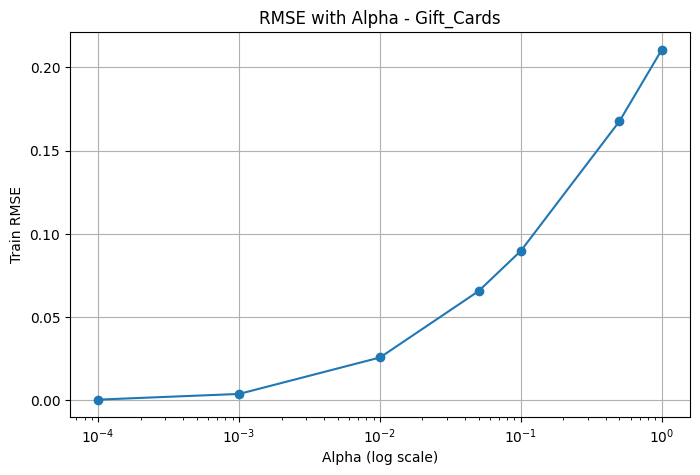

In [ ]:
CBF_Gift_Cards_model.plot_rmse_vs_alpha()

####Load and evaluate model

In [ ]:
CBF_Gift_Cards_model = ContentBasedModel(
    data_path=data_path,
    folder='Gift_Cards/',
    file_name='Gift_Cards'
)

CBF_Gift_Cards_model.run_loaded_evaluate(save_path)


🔹 Loading data for: Gift_Cards

🔹 Preprocessing item metadata...

🔹 Vectorizing using TF-IDF...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Train RMSE: 0.000405734164708166, MAE: 4.80103976845486e-05

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Test RMSE: 0.4754562013266109, MAE: 0.11807994112508105

📌 Metrics saved with key prefix 'CBF_Gift_Cards'


###Cell_Phones_and_Accessories

#### First train and save model

In [ ]:
CBF_Cell_Phones_and_Accessories_model = ContentBasedModel(
    data_path=data_path,
    folder='Cell_Phones_and_Accessories/',
    file_name='Cell_Phones_and_Accessories',
    max_features=500,
    alphas=alphas,
)

CBF_Cell_Phones_and_Accessories_model.run_train_and_save(save_path)


🔹 Loading data for: Cell_Phones_and_Accessories

🔹 Preprocessing item metadata...

🔹 Vectorizing using TF-IDF...

🔹 Training model with alpha=0.0001...


🔄 Training Users:   0%|          | 0/380999 [00:00<?, ?it/s]

✅ Training done in 1798.29s

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/380999 [00:00<?, ?it/s]

📊 Train RMSE: 0.0027115756194109387, MAE: 0.00010139449012005779
Alpha 0.0001 - Train RMSE: 0.0027115756194109387

🔹 Training model with alpha=0.001...


...

📊 Train RMSE: 0.5690370347853031, MAE: 0.39338935929713537
Alpha 1.0 - Train RMSE: 0.5690370347853031
💾 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/CBF_Cell_Phones_and_Accessories.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/380999 [00:00<?, ?it/s]

📊 Train RMSE: 0.0027115756194109387, MAE: 0.00010139449012005779

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/380999 [00:00<?, ?it/s]

📊 Test RMSE: 1.300156673741003, MAE: 0.8975134279806758

📌 Best alpha: 0.0001	RMSE: 0.0027115756194109387	MAE:0.00010139449012005779
📌 Metrics saved with key prefix 'CBF_Cell_Phones_and_Accessories'


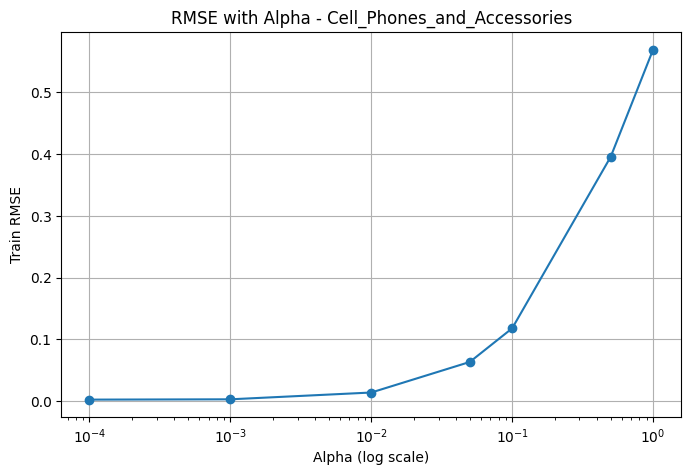

In [ ]:
CBF_Cell_Phones_and_Accessories_model.plot_rmse_vs_alpha()

#### Load and evaluate model

In [ ]:
CBF_Cell_Phones_and_Accessories_model = ContentBasedModel(
    data_path=data_path,
    folder='Cell_Phones_and_Accessories/',
    file_name='Cell_Phones_and_Accessories'
)

CBF_Cell_Phones_and_Accessories_model.run_loaded_evaluate(save_path)


🔹 Loading data for: Cell_Phones_and_Accessories

🔹 Preprocessing item metadata...

🔹 Vectorizing using TF-IDF...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/380999 [00:00<?, ?it/s]

📊 Train RMSE: 0.0027115756194109387, MAE: 0.00010139449012005779

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/380999 [00:00<?, ?it/s]

📊 Test RMSE: 1.300156673741003, MAE: 0.8975134279806758

📌 Metrics saved with key prefix 'CBF_Cell_Phones_and_Accessories'


### MovieLens 1M

In [ ]:
CBF_ml1m_model = ContentBasedModel(
    data_path=data_path,
    folder='ml-1m/',
    file_name='ml-1m',
    max_features=500,
    alphas=alphas
)

CBF_ml1m_model.run_train_and_save(save_path)


🔹 Loading data for: ml-1m

🔹 Preprocessing item metadata...

🔹 Vectorizing using TF-IDF...

🔹 Training model with alpha=0.0001...


🔄 Training Users:   0%|          | 0/6040 [00:00<?, ?it/s]

✅ Training done in 83.67s

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/6040 [00:00<?, ?it/s]

📊 Train RMSE: 0.5636909654220011, MAE: 0.32658904797281996
Alpha 0.0001 - Train RMSE: 0.5636909654220011

🔹 Training model with alpha=0.001...


...

📊 Train RMSE: 0.7500894387232099, MAE: 0.5875008757955439
Alpha 1.0 - Train RMSE: 0.7500894387232099
💾 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/CBF_ml-1m.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/6040 [00:00<?, ?it/s]

📊 Train RMSE: 0.5636909654220011, MAE: 0.32658904797281996

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/6040 [00:00<?, ?it/s]

📊 Test RMSE: 2.065163259451207, MAE: 1.4258220628517233

📌 Best alpha: 0.0001	RMSE: 0.5636909654220011	MAE:0.32658904797281996
📌 Metrics saved with key prefix 'CBF_ml-1m'


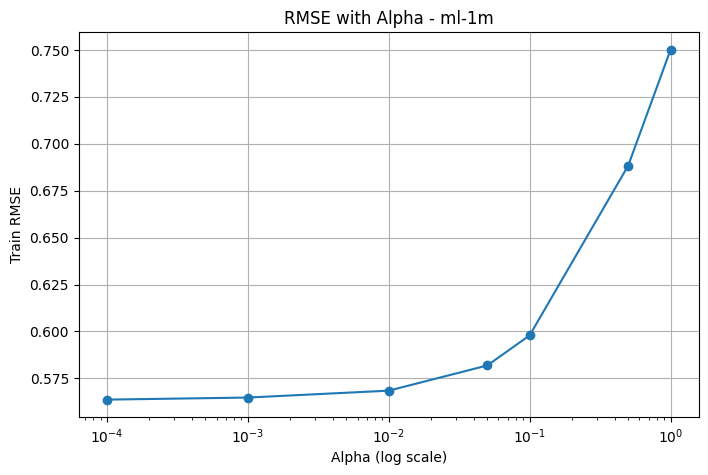

In [ ]:
CBF_ml1m_model.plot_rmse_vs_alpha()

In [ ]:
CBF_ml1m_model = ContentBasedModel(
    data_path=data_path,
    folder='ml-1m/',
    file_name='ml-1m'
)

CBF_ml1m_model.run_loaded_evaluate(save_path)


🔹 Loading data for: ml-1m

🔹 Preprocessing item metadata...

🔹 Vectorizing using TF-IDF...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/6040 [00:00<?, ?it/s]

📊 Train RMSE: 0.5636909654220011, MAE: 0.32658904797281996

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/6040 [00:00<?, ?it/s]

📊 Test RMSE: 2.065163259451207, MAE: 1.4258220628517233

📌 Metrics saved with key prefix 'CBF_ml-1m'


##Neighborhood-based collaborative filtering (NBCF)

###User-user collaborative filtering (UUCF)

####UUCF Model

In [ ]:
class UserUserCFModel:
    def __init__(self, data_path, folder, file_name, batch_size=1000, k=100):
        self.data_path = data_path
        self.folder = folder
        self.file_name = file_name
        self.batch_size = batch_size
        self.k = k

        self.rate_train = None
        self.rate_test = None
        self.n_users = 0
        self.n_items = 0
        self.Y_data = None
        self.mu = None
        self.topk_sparse_matrix = None
        self.user_item_rating_dict = {}

    def load_data(self):
        print(f"\n🔹 Loading data for: {self.file_name}")
        train_path = os.path.join(self.data_path, self.folder, self.file_name + ".train.rating")
        test_path = os.path.join(self.data_path, self.folder, self.file_name + ".test.rating")

        self.rate_train = pd.read_csv(train_path, sep="\t", header=None).astype({0: 'int32', 1: 'int32', 2: 'float32'}).to_numpy()
        self.rate_test = pd.read_csv(test_path, sep="\t", header=None).astype({0: 'int32', 1: 'int32', 2: 'float32'}).to_numpy()

        self.n_users = int(max(np.max(self.rate_train[:, 0]), np.max(self.rate_test[:, 0]))) + 1
        self.n_items = int(max(np.max(self.rate_train[:, 1]), np.max(self.rate_test[:, 1]))) + 1

        self.Y_data = self.rate_train.copy()
        print(f"✅ Loaded: {self.n_users} users, {self.n_items} items")

    def normalize_Y(self):
        print("🔹 Normalizing Y...")
        self.mu = np.zeros(self.n_users, dtype=np.float32)
        Ybar = self.Y_data.copy()

        for u in tqdm(range(self.n_users), desc="🔁 Normalize users"):
            idx = np.where(self.Y_data[:, 0] == u)[0]
            if len(idx) == 0:
                continue
            ratings = self.Y_data[idx, 2]
            mean_rating = np.mean(ratings)
            self.mu[u] = mean_rating
            Ybar[idx, 2] -= mean_rating
        return Ybar

    def train(self):
        print("🔹 Training...")
        start_time = time.time()

        Ybar = self.normalize_Y()
        rows, cols, data = Ybar[:, 0].astype(int), Ybar[:, 1].astype(int), Ybar[:, 2]
        R = csr_matrix((data, (rows, cols)), shape=(self.n_users, self.n_items), dtype=np.float32)

        row_idx, col_idx, sim_val = [], [], []

        for u_start in tqdm(range(0, self.n_users, self.batch_size), desc="🔁 Computing similarity"):
            u_end = min(u_start + self.batch_size, self.n_users)
            R_batch = R[u_start:u_end]
            sim_batch = cosine_similarity(R_batch, R, dense_output=False)

            for i, u in enumerate(range(u_start, u_end)):
                row = sim_batch.getrow(i)
                row.data[row.indices == u] = -1  # loại chính nó
                if row.nnz == 0:
                    continue
                top_k_idx = np.argsort(row.data)[-self.k:]
                for idx in top_k_idx:
                    v = row.indices[idx]
                    sim = row.data[idx]
                    if sim <= 0:
                        continue
                    row_idx.append(u)
                    col_idx.append(v)
                    sim_val.append(sim)

            del R_batch, sim_batch
            gc.collect()

        self.topk_sparse_matrix = csr_matrix((sim_val, (row_idx, col_idx)), shape=(self.n_users, self.n_users), dtype=np.float32)
        self.user_item_rating_dict = self.build_lookup(self.Y_data)

        print(f"✅ Training complete in {time.time() - start_time:.2f}s")

    def build_lookup(self, Y_data):
        return {(int(u), int(i)): float(r) for u, i, r in Y_data}

    def estimate(self, user_id, item_id):
        user_id = int(user_id)
        item_id = int(item_id)

        if self.topk_sparse_matrix is None or user_id >= self.topk_sparse_matrix.shape[0]:
            return self.mu[user_id]

        row = self.topk_sparse_matrix.getrow(user_id)
        top_sims, top_ratings = [], []

        for v, sim in zip(row.indices, row.data):
            rating = self.user_item_rating_dict.get((v, item_id))
            if rating is not None:
                top_sims.append(sim)
                top_ratings.append(rating)

        if len(top_sims) == 0 or np.sum(np.abs(top_sims)) == 0:
            return self.mu[user_id]

        rating_hat = np.dot(top_sims, top_ratings) / np.sum(np.abs(top_sims))
        return float(np.clip(rating_hat + self.mu[user_id], 1, 5))

    def evaluate(self, rate_matrix, name="Test"):
        print(f"\n🔍 Evaluating on {name} set...")
        start_time = time.time()
        se_total, mae_total = 0.0, 0.0
        count = rate_matrix.shape[0]

        for start in tqdm(range(0, count, self.batch_size), desc=f"📊 {name} Evaluation"):
            end = min(start + self.batch_size, count)
            batch = rate_matrix[start:end]
            users, items, true_ratings = batch[:, 0], batch[:, 1], batch[:, 2]

            preds = np.array([self.estimate(u, i) for u, i in zip(users, items)], dtype=np.float32)
            errs = true_ratings - preds
            se_total += np.sum(errs ** 2)
            mae_total += np.sum(np.abs(errs))

        rmse = np.sqrt(se_total / count)
        mae = mae_total / count
        print(f"📊 {name} RMSE: {rmse:.4f}, MAE: {mae:.4f}")
        print(f"⏱️ Evaluation time: {time.time() - start_time:.2f}s")
        return rmse, mae

    def run_train_and_save(self, save_path):
        self.load_data()
        self.train()
        self.save_model(save_path)

        rmse_train, mae_train = self.evaluate(self.rate_train, name="Train")
        rmse_test, mae_test = self.evaluate(self.rate_test, name="Test")

        key_prefix = f"UUCF_{self.file_name}"
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Train"] = rmse_train
        GLOBAL_METRICS[f"MAE_{key_prefix}_Train"] = mae_train
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Test"] = rmse_test
        GLOBAL_METRICS[f"MAE_{key_prefix}_Test"] = mae_test

        print(f"\n📌 Metrics saved with key prefix '{key_prefix}'")

    def run_loaded_evaluate(self, load_path):
        self.load_model(load_path)

        rmse_train, mae_train = self.evaluate(self.rate_train, name="Train")
        rmse_test, mae_test = self.evaluate(self.rate_test, name="Test")

        key_prefix = f"UUCF_{self.file_name}"
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Train"] = rmse_train
        GLOBAL_METRICS[f"MAE_{key_prefix}_Train"] = mae_train
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Test"] = rmse_test
        GLOBAL_METRICS[f"MAE_{key_prefix}_Test"] = mae_test

        print(f"\n📌 Metrics saved with key prefix '{key_prefix}'")

    def save_model(self, save_path):
        model_data = {
            "topk_sparse_matrix": self.topk_sparse_matrix,
            "mu": self.mu,
        }
        file = os.path.join(save_path, f"uuCF_{self.file_name}.pkl")
        joblib.dump(model_data, file, compress=3)
        print(f"📂 Model saved to {file}")

    def load_model(self, load_path):
        self.load_data()
        file = os.path.join(load_path, f"uuCF_{self.file_name}.pkl")
        model_data = joblib.load(file)
        self.topk_sparse_matrix = model_data["topk_sparse_matrix"]
        self.mu = model_data["mu"]
        self.user_item_rating_dict = self.build_lookup(self.rate_train)
        print("✅ Model loaded successfully.")

####Gift_Cards

##### First train and save model

In [ ]:
uuCF_Gift_Cards_model = UserUserCFModel(
    data_path=data_path,
    folder='Gift_Cards/',
    file_name='Gift_Cards',
    k=100,
    batch_size=1000
)

uuCF_Gift_Cards_model.run_train_and_save(save_path)


🔹 Loading data for: Gift_Cards
✅ Loaded: 377 users, 129 items
🔹 Training...
🔹 Normalizing Y...


🔁 Normalize users:   0%|          | 0/377 [00:00<?, ?it/s]

🔁 Computing similarity:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete in 0.24s
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/uuCF_Gift_Cards.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

📊 Train RMSE: 0.4018, MAE: 0.0771
⏱️ Evaluation time: 0.17s

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/1 [00:00<?, ?it/s]

📊 Test RMSE: 0.4042, MAE: 0.0790
⏱️ Evaluation time: 0.05s

📌 Metrics saved with key prefix 'UUCF_Gift_Cards'


##### Load and evaluate model

In [ ]:
uuCF_Gift_Cards_model = UserUserCFModel(
    data_path=data_path,
    folder='Gift_Cards/',
    file_name='Gift_Cards'
)

uuCF_Gift_Cards_model.run_loaded_evaluate(save_path)


🔹 Loading data for: Gift_Cards
✅ Loaded: 377 users, 129 items
✅ Model loaded successfully.

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

📊 Train RMSE: 0.4018, MAE: 0.0771
⏱️ Evaluation time: 0.14s

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/1 [00:00<?, ?it/s]

📊 Test RMSE: 0.4042, MAE: 0.0790
⏱️ Evaluation time: 0.07s

📌 Metrics saved with key prefix 'UUCF_Gift_Cards'


- Test rating

In [ ]:
pred_train = uuCF_Gift_Cards_model.estimate(user_id=72, item_id=84)
print("Predicted rating in train:", pred_train)

pred_test = uuCF_Gift_Cards_model.estimate(user_id=72, item_id=57)
print("Predicted rating in test:", pred_test)

Predicted rating in train: 5.0
Predicted rating in test: 5.0


####Cell_Phones_and_Accessories

##### First train and save model

In [ ]:
uuCF_Cell_Phones_and_Accessories_model = UserUserCFModel(
    data_path=data_path,
    folder='Cell_Phones_and_Accessories/',
    file_name='Cell_Phones_and_Accessories',
    k=100,
    batch_size=1000
)

uuCF_Cell_Phones_and_Accessories_model.run_train_and_save(save_path)


🔹 Loading data for: Cell_Phones_and_Accessories
✅ Loaded: 380999 users, 111480 items
🔹 Training...
🔹 Normalizing Y...


🔁 Normalize users:   0%|          | 0/380999 [00:00<?, ?it/s]

🔁 Computing similarity:   0%|          | 0/381 [00:00<?, ?it/s]

✅ Training complete in 3306.11s
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/uuCF_Cell_Phones_and_Accessories.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2372 [00:00<?, ?it/s]

📊 Train RMSE: 1.3849, MAE: 0.7296
⏱️ Evaluation time: 519.94s

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/381 [00:00<?, ?it/s]

📊 Test RMSE: 1.2983, MAE: 0.8728
⏱️ Evaluation time: 51.26s

📌 Metrics saved with key prefix 'UUCF_Cell_Phones_and_Accessories'


##### Load and evaluate model

In [ ]:
uuCF_Cell_Phones_and_Accessories_model = UserUserCFModel(
    data_path=data_path,
    folder='Cell_Phones_and_Accessories/',
    file_name='Cell_Phones_and_Accessories'
)

uuCF_Cell_Phones_and_Accessories_model.run_loaded_evaluate(save_path)


🔹 Loading data for: Cell_Phones_and_Accessories
✅ Loaded: 380999 users, 111480 items
✅ Model loaded successfully.

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2372 [00:00<?, ?it/s]

📊 Train RMSE: 1.3849, MAE: 0.7296
⏱️ Evaluation time: 528.28s

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/381 [00:00<?, ?it/s]

📊 Test RMSE: 1.2983, MAE: 0.8728
⏱️ Evaluation time: 52.28s

📌 Metrics saved with key prefix 'UUCF_Cell_Phones_and_Accessories'


- Test rating

In [ ]:
print("Predicted train:", uuCF_Cell_Phones_and_Accessories_model.estimate(72, 78717))
print("Predicted test :", uuCF_Cell_Phones_and_Accessories_model.estimate(72, 60187))

Predicted train: 5.0
Predicted test : 5.0


####MovieLens 1M

##### First init, run and save model

In [ ]:
uuCF_ml1m_model = UserUserCFModel(
    data_path=data_path,
    folder='ml-1m/',
    file_name='ml-1m',
    k=100,
    batch_size=1000
)

uuCF_ml1m_model.run_train_and_save(save_path)


🔹 Loading data for: ml-1m
✅ Loaded: 6040 users, 3706 items
🔹 Training...
🔹 Normalizing Y...


🔁 Normalize users:   0%|          | 0/6040 [00:00<?, ?it/s]

🔁 Computing similarity:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Training complete in 31.33s
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/uuCF_ml-1m.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/995 [00:00<?, ?it/s]

📊 Train RMSE: 1.7827, MAE: 1.4024
⏱️ Evaluation time: 332.46s

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

📊 Test RMSE: 1.7769, MAE: 1.3603
⏱️ Evaluation time: 1.72s

📌 Metrics saved with key prefix 'UUCF_ml-1m'


##### Load & evaluate model

In [ ]:
uuCF_ml1m_model = UserUserCFModel(
    data_path=data_path,
    folder='ml-1m/',
    file_name='ml-1m'
)

uuCF_ml1m_model.run_loaded_evaluate(save_path)


🔹 Loading data for: ml-1m
✅ Loaded: 6040 users, 3706 items
✅ Model loaded successfully.

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/995 [00:00<?, ?it/s]

📊 Train RMSE: 1.7827, MAE: 1.4024
⏱️ Evaluation time: 332.63s

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

📊 Test RMSE: 1.7769, MAE: 1.3603
⏱️ Evaluation time: 1.74s

📌 Metrics saved with key prefix 'UUCF_ml-1m'


###Item-item collaborative filtering (IICF)

####IICF Model

In [ ]:
class ItemItemCFModel:
    def __init__(self, data_path, folder, file_name, batch_size=1000, k=100, only_evaluate=False):
        self.data_path = data_path
        self.folder = folder
        self.file_name = file_name
        self.batch_size = batch_size
        self.k = k
        self.only_evaluate = only_evaluate

        self.rate_train = None
        self.rate_test = None
        self.n_users = 0
        self.n_items = 0
        self.Y_data = None
        self.Ybar = None
        self.mu = None
        self.topk_sparse_matrix = None
        self.user_item_rating_dict = {}

    def load_data(self):
        """Load train and test rating data from file."""
        print(f"\n🔹 Loading data for: {self.file_name}")
        train_path = os.path.join(self.data_path, self.folder, self.file_name + ".train.rating")
        test_path = os.path.join(self.data_path, self.folder, self.file_name + ".test.rating")

        self.rate_train = pd.read_csv(train_path, sep="\t", header=None)\
            .astype({0: 'int32', 1: 'int32', 2: 'float32'}).to_numpy()
        self.rate_test = pd.read_csv(test_path, sep="\t", header=None)\
            .astype({0: 'int32', 1: 'int32', 2: 'float32'}).to_numpy()

        self.n_users = int(max(np.max(self.rate_train[:, 0]), np.max(self.rate_test[:, 0]))) + 1
        self.n_items = int(max(np.max(self.rate_train[:, 1]), np.max(self.rate_test[:, 1]))) + 1

        self.Y_data = self.rate_train.copy()
        print(f"✅ Loaded: {self.n_users} users, {self.n_items} items")

    def normalize_Y(self, Y):
        """Normalize ratings by subtracting item mean."""
        print("🔹 Normalizing Y (by item)...")
        items = Y[:, 1]
        self.mu = np.zeros(self.n_items, dtype=np.float32)
        Ybar = Y.copy()
        for i in tqdm(range(self.n_items), desc="🔁 Normalizing per item"):
            idxs = np.where(items == i)[0]
            if len(idxs) == 0:
                continue
            ratings = Y[idxs, 2]
            mean = np.mean(ratings)
            self.mu[i] = mean
            Ybar[idxs, 2] = ratings - mean
        return Ybar

    def train(self):
        """Train model by computing item-item similarity matrix."""
        print("🔹 Training (computing item-item similarity)...")
        start_time = time.time()

        self.Ybar = self.normalize_Y(self.Y_data)
        rows = self.Ybar[:, 0].astype(int)
        cols = self.Ybar[:, 1].astype(int)
        data = self.Ybar[:, 2]

        R = csr_matrix((data, (rows, cols)), shape=(self.n_users, self.n_items), dtype=np.float32)

        row_idx, col_idx, sim_val = [], [], []

        for i_start in tqdm(range(0, self.n_items, self.batch_size), desc="🔁 Item blocks"):
            i_end = min(i_start + self.batch_size, self.n_items)
            R_batch = R[:, i_start:i_end].T
            sim_batch = cosine_similarity(R_batch, R.T, dense_output=False)

            for i_local, item_i in enumerate(range(i_start, i_end)):
                row = sim_batch.getrow(i_local)
                mask_self = row.indices == item_i
                if np.any(mask_self):
                    row.data[mask_self] = -1

                if row.nnz == 0:
                    continue
                top_k_idx = np.argsort(row.data)[-self.k:]
                for idx in top_k_idx:
                    sim = row.data[idx]
                    if sim <= 0:
                        continue
                    j = row.indices[idx]
                    row_idx.append(item_i)
                    col_idx.append(j)
                    sim_val.append(sim)

            del R_batch, sim_batch
            gc.collect()

        self.topk_sparse_matrix = csr_matrix((sim_val, (row_idx, col_idx)), shape=(self.n_items, self.n_items), dtype=np.float32)
        del R
        gc.collect()

        print("✅ Training complete.")
        print(f"⏱️ Training time: {time.time() - start_time:.2f} seconds")

    def build_lookup(self, Y_data):
        """Build lookup dictionary for fast user-item rating query."""
        return {(int(u), int(i)): float(r) for u, i, r in Y_data}

    def estimate(self, user_id, item_id):
        """Estimate rating user_id gives item_id."""
        user_id = int(user_id)
        item_id = int(item_id)

        if self.topk_sparse_matrix is None or item_id >= self.topk_sparse_matrix.shape[0]:
            return float(self.mu[item_id])

        row = self.topk_sparse_matrix.getrow(item_id)
        sims, ratings = [], []

        for j, sim in zip(row.indices, row.data):
            r_uj = self.user_item_rating_dict.get((user_id, j))
            if r_uj is not None:
                sims.append(sim)
                ratings.append(r_uj - self.mu[j])

        if len(sims) == 0 or np.sum(np.abs(sims)) == 0:
            return float(self.mu[item_id])

        rating_hat = np.dot(sims, ratings) / np.sum(np.abs(sims))
        return float(np.clip(rating_hat + self.mu[item_id], 1, 5))

    def evaluate(self, rate_matrix, name="Test"):
        """Evaluate model performance on given rating matrix."""
        print(f"\n🔍 Evaluating on {name} set...")
        start_time = time.time()

        se_total, mae_total, count = 0.0, 0.0, 0
        total = rate_matrix.shape[0]

        rating_dict = self.user_item_rating_dict
        mu = self.mu
        sim_matrix = self.topk_sparse_matrix

        with tqdm(total=total, desc=f"📊 {name} Evaluation") as pbar:
            for start in range(0, total, self.batch_size):
                end = min(start + self.batch_size, total)
                batch = rate_matrix[start:end]
                users = batch[:, 0].astype(int)
                items = batch[:, 1].astype(int)
                true_ratings = batch[:, 2]

                preds = np.zeros(len(users), dtype=np.float32)

                for idx, (u, i) in enumerate(zip(users, items)):
                    u, i = int(u), int(i)
                    if i >= sim_matrix.shape[0]:
                        preds[idx] = mu[i]
                        continue

                    row = sim_matrix.getrow(i)
                    sims, ratings = [], []

                    for j, sim in zip(row.indices, row.data):
                        r_uj = rating_dict.get((u, j), None)
                        if r_uj is not None:
                            sims.append(sim)
                            ratings.append(r_uj - mu[j])

                    if len(sims) == 0 or np.sum(np.abs(sims)) == 0:
                        preds[idx] = mu[i]
                    else:
                        rating_hat = np.dot(sims, ratings) / np.sum(np.abs(sims))
                        preds[idx] = np.clip(rating_hat + mu[i], 1, 5)

                    pbar.update(1)

                errs = true_ratings - preds
                se_total += np.sum(errs ** 2)
                mae_total += np.sum(np.abs(errs))
                count += len(users)
                gc.collect()

        rmse = np.sqrt(se_total / count)
        mae = mae_total / count
        print(f"📊 {name} RMSE: {rmse:.4f}, MAE: {mae:.4f}")
        print(f"⏱️ {name} Evaluation time: {time.time() - start_time:.2f} seconds")
        return rmse, mae

    def save_model(self, save_path):
        """Save trained model to disk."""
        model_data = {
            "topk_sparse_matrix": self.topk_sparse_matrix,
            "mu": self.mu.astype(np.float32),
        }
        full_path = os.path.join(save_path, 'iiCF_' + self.file_name + '.pkl')
        joblib.dump(model_data, full_path, compress=3)
        print(f"📂 Model saved to {full_path}")

    def load_model(self, load_path):
        """Load model from disk and load data for evaluation."""
        self.load_data()

        full_path = os.path.join(load_path, 'iiCF_' + self.file_name + '.pkl')
        with open(full_path, 'rb') as f:
            model_data = joblib.load(f)
        self.topk_sparse_matrix = model_data["topk_sparse_matrix"]
        self.mu = model_data["mu"]

        self.user_item_rating_dict = self.build_lookup(self.rate_train)
        print("✅ Model loaded successfully.")

    def run_train_and_save(self, save_path):
        """Full pipeline: load data, train model, save model."""
        self.load_data()
        self.train()
        self.user_item_rating_dict = self.build_lookup(self.Y_data)
        self.save_model(save_path)

        rmse_train, mae_train = self.evaluate(self.rate_train, name="Train")
        rmse_test, mae_test = self.evaluate(self.rate_test, name="Test")

        key_prefix = f"IICF_{self.file_name}"
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Train"] = rmse_train
        GLOBAL_METRICS[f"MAE_{key_prefix}_Train"] = mae_train
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Test"] = rmse_test
        GLOBAL_METRICS[f"MAE_{key_prefix}_Test"] = mae_test

        print(f"\n📌 Metrics saved with key prefix '{key_prefix}'")
        gc.collect()

    def run_loaded_evaluate(self, load_path):
        """Load model and data, then evaluate on train and test sets."""
        self.load_model(load_path)
        rmse_train, mae_train = self.evaluate(self.rate_train, name="Train")
        rmse_test, mae_test = self.evaluate(self.rate_test, name="Test")

        key_prefix = f"IICF_{self.file_name}"
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Train"] = rmse_train
        GLOBAL_METRICS[f"MAE_{key_prefix}_Train"] = mae_train
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Test"] = rmse_test
        GLOBAL_METRICS[f"MAE_{key_prefix}_Test"] = mae_test

        print(f"\n📌 Metrics saved with key prefix '{key_prefix}'")

####Gift_Cards

##### First train and save model

In [ ]:
iiCF_Gift_Cards_model = ItemItemCFModel(
    data_path=data_path,
    folder='Gift_Cards/',
    file_name='Gift_Cards',
    batch_size=1000
)

iiCF_Gift_Cards_model.run_train_and_save(save_path)


🔹 Loading data for: Gift_Cards
✅ Loaded: 377 users, 129 items
🔹 Training (computing item-item similarity)...
🔹 Normalizing Y (by item)...


🔁 Normalizing per item:   0%|          | 0/129 [00:00<?, ?it/s]

🔁 Item blocks:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete.
⏱️ Training time: 0.48 seconds
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/iiCF_Gift_Cards.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2052 [00:00<?, ?it/s]

📊 Train RMSE: 0.3652, MAE: 0.0918
⏱️ Train Evaluation time: 0.74 seconds

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Test RMSE: 0.5328, MAE: 0.1620
⏱️ Test Evaluation time: 0.23 seconds

📌 Metrics saved with key prefix 'IICF_Gift_Cards'


##### Load and evaluate model

In [ ]:
iiCF_Gift_Cards_model = ItemItemCFModel(
    data_path=data_path,
    folder="Gift_Cards",
    file_name="Gift_Cards",
)

iiCF_Gift_Cards_model.run_loaded_evaluate(save_path)


🔹 Loading data for: Gift_Cards
✅ Loaded: 377 users, 129 items
✅ Model loaded successfully.

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2052 [00:00<?, ?it/s]

📊 Train RMSE: 0.3652, MAE: 0.0918
⏱️ Train Evaluation time: 0.72 seconds

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Test RMSE: 0.5328, MAE: 0.1620
⏱️ Test Evaluation time: 0.21 seconds

📌 Metrics saved with key prefix 'IICF_Gift_Cards'


####Cell_Phones_and_Accessories

##### First train and save model

In [ ]:
iiCF_Cell_Phones_and_Accessories_model = ItemItemCFModel(
    data_path=data_path,
    folder='Cell_Phones_and_Accessories/',
    file_name='Cell_Phones_and_Accessories',
    batch_size=1000
)

iiCF_Cell_Phones_and_Accessories_model.run_train_and_save(save_path)


🔹 Loading data for: Cell_Phones_and_Accessories
✅ Loaded: 380999 users, 111480 items
🔹 Training (computing item-item similarity)...
🔹 Normalizing Y (by item)...


🔁 Normalizing per item:   0%|          | 0/111480 [00:00<?, ?it/s]

🔁 Item blocks:   0%|          | 0/112 [00:00<?, ?it/s]

✅ Training complete.
⏱️ Training time: 935.92 seconds
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/iiCF_Cell_Phones_and_Accessories.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2371786 [00:00<?, ?it/s]

📊 Train RMSE: 0.8244, MAE: 0.5314
⏱️ Train Evaluation time: 779.23 seconds

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/380999 [00:00<?, ?it/s]

📊 Test RMSE: 1.2868, MAE: 0.9613
⏱️ Test Evaluation time: 103.11 seconds

📌 Metrics saved with key prefix 'IICF_Cell_Phones_and_Accessories'


##### Load and evaluate model

In [ ]:
iiCF_Cell_Phones_and_Accessories_model = ItemItemCFModel(
    data_path=data_path,
    folder="Cell_Phones_and_Accessories",
    file_name="Cell_Phones_and_Accessories",
)

iiCF_Cell_Phones_and_Accessories_model.run_loaded_evaluate(save_path)


🔹 Loading data for: Cell_Phones_and_Accessories
✅ Loaded: 380999 users, 111480 items
✅ Model loaded successfully.

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2371786 [00:00<?, ?it/s]

📊 Train RMSE: 0.8244, MAE: 0.5314
⏱️ Train Evaluation time: 776.68 seconds

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/380999 [00:00<?, ?it/s]

📊 Test RMSE: 1.2868, MAE: 0.9613
⏱️ Test Evaluation time: 102.89 seconds

📌 Metrics saved with key prefix 'IICF_Cell_Phones_and_Accessories'


####MovieLens 1M

##### First train and save model

In [ ]:
iiCF_ml1m_model = ItemItemCFModel(
    data_path=data_path,
    folder='ml-1m/',
    file_name='ml-1m',
    batch_size=1000
)

iiCF_ml1m_model.run_train_and_save(save_path)


🔹 Loading data for: ml-1m
✅ Loaded: 6040 users, 3706 items
🔹 Training (computing item-item similarity)...
🔹 Normalizing Y (by item)...


🔁 Normalizing per item:   0%|          | 0/3706 [00:00<?, ?it/s]

🔁 Item blocks:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Training complete.
⏱️ Training time: 17.69 seconds
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/iiCF_ml-1m.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/994169 [00:00<?, ?it/s]

📊 Train RMSE: 0.7816, MAE: 0.6077
⏱️ Train Evaluation time: 508.00 seconds

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/6040 [00:00<?, ?it/s]

📊 Test RMSE: 0.9419, MAE: 0.7261
⏱️ Test Evaluation time: 2.83 seconds

📌 Metrics saved with key prefix 'IICF_ml-1m'


##### Load and evaluate model

In [ ]:
iiCF_ml1m_model = ItemItemCFModel(
    data_path=data_path,
    folder="ml-1m",
    file_name="ml-1m",
)

iiCF_ml1m_model.run_loaded_evaluate(save_path)


🔹 Loading data for: ml-1m
✅ Loaded: 6040 users, 3706 items
✅ Model loaded successfully.

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/994169 [00:00<?, ?it/s]

📊 Train RMSE: 0.7816, MAE: 0.6077
⏱️ Train Evaluation time: 508.87 seconds

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/6040 [00:00<?, ?it/s]

📊 Test RMSE: 0.9419, MAE: 0.7261
⏱️ Test Evaluation time: 2.68 seconds

📌 Metrics saved with key prefix 'IICF_ml-1m'


##Matrix factorization collaborative filtering (MFCF)

###MFCF Model

In [ ]:
class MFCFModel:
    def __init__(self, data_path, folder, file_name, k=50, lam=0.1, learning_rate=[0.01],
                 max_iter=50, print_every=1, solver="SGD", batch_size=512):
        self.data_path = data_path
        self.folder = folder
        self.file_name = file_name
        self.k = k
        self.lam = lam
        self.learning_rate = learning_rate if isinstance(learning_rate, list) else [learning_rate]
        self.max_iter = max_iter
        self.print_every = print_every
        self.solver = solver.upper()
        self.batch_size = batch_size

        self.rate_train = None
        self.rate_test = None
        self.n_users = 0
        self.n_items = 0
        self.X = None
        self.W = None
        self.mu = None
        self.Y_data_n = None
        self.loss_history = []
        self.R = None

    def load_data(self):
        print(f"\n🔹 Loading data for: {self.file_name}")
        train_path = os.path.join(self.data_path, self.folder, self.file_name + ".train.rating")
        test_path = os.path.join(self.data_path, self.folder, self.file_name + ".test.rating")

        self.rate_train = pd.read_csv(train_path, sep="\t", header=None)\
            .astype({0: 'int32', 1: 'int32', 2: 'float32'}).to_numpy()
        self.rate_test = pd.read_csv(test_path, sep="\t", header=None)\
            .astype({0: 'int32', 1: 'int32', 2: 'float32'}).to_numpy()

        self.n_users = int(max(np.max(self.rate_train[:, 0]), np.max(self.rate_test[:, 0]))) + 1
        self.n_items = int(max(np.max(self.rate_train[:, 1]), np.max(self.rate_test[:, 1]))) + 1

        self.Y_data_n = self.rate_train.copy()
        self.normalize_Y()

        self.R = np.zeros((self.n_users, self.n_items), dtype=np.float32)
        for u, i, r in self.Y_data_n:
            self.R[int(u), int(i)] = r

    def normalize_Y(self):
        print("🔹 Normalizing Y (per user mean)...")
        self.mu = np.zeros(self.n_users, dtype=np.float32)
        for n in tqdm(range(self.n_users), desc="🔁 Normalizing per user"):
            ids = np.where(self.Y_data_n[:, 0] == n)[0]
            if len(ids) == 0:
                continue
            ratings = self.Y_data_n[ids, 2]
            mean = np.mean(ratings) if len(ratings) > 0 else 0.0
            self.mu[n] = mean
            self.Y_data_n[ids, 2] -= mean

    def train(self):
        print(f"🔹 Training MF model using solver: {self.solver}")
        if self.solver == "SGD":
            self.train_sgd()
        elif self.solver == "ALS":
            self.train_als()
        else:
            raise ValueError(f"❌ Unknown solver: {self.solver}")

    def train_sgd(self):
        self.X = 0.01 * np.random.randn(self.n_items, self.k).astype(np.float32)
        self.W = 0.01 * np.random.randn(self.k, self.n_users).astype(np.float32)

        early_stop_count = 0
        early_stop_threshold = 5
        prev_loss = float("inf")

        for it in range(self.max_iter):
            np.random.shuffle(self.Y_data_n)
            for start in range(0, len(self.Y_data_n), self.batch_size):
                end = start + self.batch_size
                batch = self.Y_data_n[start:end]
                u_batch = batch[:, 0].astype(np.int32)  # shape (B,)
                i_batch = batch[:, 1].astype(np.int32)  # shape (B,)
                r_batch = batch[:, 2]                   # shape (B,)

                # Lấy ma trận con của X và W
                X_i = self.X[i_batch]                   # shape (B, k)
                W_u = self.W[:, u_batch].T              # shape (B, k)

                pred = np.sum(X_i * W_u, axis=1)        # shape (B,)
                err = r_batch - pred                    # shape (B,)

                # Vector hóa cập nhật
                grad_X = err[:, np.newaxis] * W_u - self.lam * X_i   # shape (B, k)
                grad_W = err[:, np.newaxis] * X_i - self.lam * W_u   # shape (B, k)

                # Cập nhật X và W bằng chỉ số
                np.add.at(self.X, i_batch, self.learning_rate_current * grad_X)
                for idx, u in enumerate(u_batch):
                    self.W[:, u] += self.learning_rate_current * grad_W[idx]


            # Logging loss
            if (it + 1) % self.print_every == 0 or it == self.max_iter - 1:
                loss = self.compute_loss()
                self.loss_history.append((it + 1, loss))
                print(f"   🔁 Iter {it+1}/{self.max_iter} - Loss: {loss:.4f}")

                # Early stopping
                if abs(prev_loss - loss) < 1e-4:
                    early_stop_count += 1
                    if early_stop_count >= early_stop_threshold:
                        print("🛑 Early stopping triggered.")
                        break
                else:
                    early_stop_count = 0
                prev_loss = loss


    def train_als(self):
        from numpy.linalg import solve
        self.X = np.random.randn(self.n_items, self.k).astype(np.float32)
        self.W = np.random.randn(self.k, self.n_users).astype(np.float32)

        I_k = np.eye(self.k, dtype=np.float32)
        for it in range(self.max_iter):
            for u in range(self.n_users):
                idx = self.R[u, :] > 0
                if np.sum(idx) == 0:
                    continue
                X_u = self.X[idx, :]
                r_u = self.R[u, idx]
                A = X_u.T @ X_u + self.lam * I_k
                V = X_u.T @ r_u
                self.W[:, u] = solve(A, V)

            for i in range(self.n_items):
                idx = self.R[:, i] > 0
                if np.sum(idx) == 0:
                    continue
                W_i = self.W[:, idx].T
                r_i = self.R[idx, i]
                A = W_i.T @ W_i + self.lam * I_k
                V = W_i.T @ r_i
                self.X[i, :] = solve(A, V)

            if (it + 1) % self.print_every == 0 or it == self.max_iter - 1:
                print(f"   🔁 ALS Iter {it+1}/{self.max_iter}")

    def compute_loss(self):
        loss = 0.0
        for u, i, r_ui in self.Y_data_n:
            u, i = int(u), int(i)
            pred = self.X[i, :].dot(self.W[:, u])
            loss += 0.5 * (r_ui - pred) ** 2
        loss /= self.Y_data_n.shape[0]
        loss += 0.5 * self.lam * (np.linalg.norm(self.X, 'fro')**2 + np.linalg.norm(self.W, 'fro')**2)
        return loss

    def estimate(self, user_id, item_id):
        if user_id >= self.n_users or item_id >= self.n_items:
            print(f"⚠️ Invalid ID: user_id={user_id}, item_id={item_id}")
            return 3.0
        pred = self.X[item_id, :].dot(self.W[:, user_id]) + self.mu[user_id]
        return float(np.clip(pred, 1, 5))

    def evaluate(self, rate_matrix, name="Test"):
        print(f"\n🔍 Evaluating on {name} set...")
        se_total, mae_total = 0.0, 0.0
        count = rate_matrix.shape[0]
        for u, i, r in tqdm(rate_matrix, desc=f"📊 {name} Evaluation"):
            u, i = int(u), int(i)
            pred = self.estimate(u, i)
            err = r - pred
            se_total += err ** 2
            mae_total += abs(err)
        rmse = np.sqrt(se_total / count)
        mae = mae_total / count
        print(f"📊 {name} RMSE: {rmse:.4f}, MAE: {mae:.4f}")
        return rmse, mae

    def save_model(self, save_path):
        os.makedirs(save_path, exist_ok=True)
        model_data = {
            "X": self.X,
            "W": self.W,
            "mu": self.mu,
            "params": {
                "data_path": self.data_path,
                "folder": self.folder,
                "file_name": self.file_name,
                "k": self.k,
                "lam": self.lam,
                "learning_rate": self.learning_rate,
                "max_iter": self.max_iter,
                "print_every": self.print_every,
                "solver": self.solver,
                "batch_size": self.batch_size,
            }
        }
        full_path = os.path.join(save_path, f'MF_{self.solver}_{self.file_name}.pkl')
        joblib.dump(model_data, full_path, compress=3)
        print(f"📂 Model saved to {full_path}")

    def load_model(self, load_path):
        full_path = os.path.join(load_path, f'MF_{self.solver}_{self.file_name}.pkl')
        if not os.path.isfile(full_path):
            raise FileNotFoundError(f"❌ Model file not found at: {full_path}")
        model_data = joblib.load(full_path)
        self.X = model_data["X"]
        self.W = model_data["W"]
        self.mu = model_data["mu"]
        if "params" in model_data:
            for key, val in model_data["params"].items():
                setattr(self, key, val)
        print("✅ Model and parameters loaded successfully.")

    def show_loss(self):
        if not self.loss_history:
            print("⚠️ Không có dữ liệu loss để hiển thị.")
            return

        epochs, losses = zip(*self.loss_history)
        plt.plot(epochs, losses, marker='o')
        plt.title(f"Training Loss with best learning rate: {self.learning_rate}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

    def plot_learning_rate_vs_rmse(self):
        if not hasattr(self, 'lr_rmse_list') or not self.lr_rmse_list:
            print("⚠️ Chưa có dữ liệu RMSE cho các learning rate. Hãy gọi run_train_and_save() trước.")
            return

        lrs, rmses = zip(*self.lr_rmse_list)

        plt.figure(figsize=(8, 5))
        plt.plot(lrs, rmses, marker='o', linestyle='-', color='teal')
        plt.title('Learning Rate vs RMSE')
        plt.xlabel('Learning Rate')
        plt.ylabel('Train RMSE')
        plt.grid(True)
        plt.xscale('log') if any(lr < 0.1 for lr in lrs) else None  # log-scale nếu có lr nhỏ
        plt.tight_layout()
        plt.show()

    def run_train_and_save(self, save_path):
          """
          Load data, train model with multiple learning rates (for SGD),
          evaluate on train/test, save best model.
          """
          self.load_data()

          best_rmse = float('inf')
          best_lr = None
          best_X = None
          best_W = None
          best_loss_history = None
          self.lr_rmse_list = []

          for lr in self.learning_rate:
              print(f"\n🚀 Training with learning rate: {lr}")
              self.learning_rate_current = lr
              self.loss_history = []
              self.train()

              print("✅ Training completed, evaluating results...")
              rmse_train, _ = self.evaluate(self.rate_train, name="Train")
              self.lr_rmse_list.append((lr, rmse_train))
              print(f"📈 Learning Rate {lr} - Train RMSE: {rmse_train:.4f}")

              if rmse_train < best_rmse:
                  best_rmse = rmse_train
                  best_lr = lr
                  best_X = self.X.copy()
                  best_W = self.W.copy()
                  best_loss_history = self.loss_history.copy()

          # Dùng mô hình tốt nhất
          self.learning_rate = best_lr
          self.X = best_X
          self.W = best_W
          self.loss_history = best_loss_history

          # Lưu mô hình
          self.save_model(save_path)

          # Đánh giá lại cả train và test
          rmse_train, mae_train = self.evaluate(self.rate_train, name="Train")
          rmse_test, mae_test = self.evaluate(self.rate_test, name="Test")

          key_prefix = f"MF_{self.file_name}_{self.solver}"
          GLOBAL_METRICS[f"RMSE_{key_prefix}_Train"] = rmse_train
          GLOBAL_METRICS[f"MAE_{key_prefix}_Train"] = mae_train
          GLOBAL_METRICS[f"RMSE_{key_prefix}_Test"] = rmse_test
          GLOBAL_METRICS[f"MAE_{key_prefix}_Test"] = mae_test

          print(f"\n📌 Best learning rate: {best_lr}\tRMSE: {rmse_train:.4f}\tMAE: {mae_train:.4f}")
          print(f"📌 Metrics saved with key prefix '{key_prefix}'")

      # def run_train_and_save(self, save_path):
      #     """
      #     Load data, train model with multiple learning rates (for SGD),
      #     split train into train/valid, evaluate on valid set, and test on separate set.
      #     Save the model with best validation RMSE.
      #     """
      #     self.load_data()

      #     # Split train into train/valid
      #     np.random.seed(42)
      #     indices = np.random.permutation(len(self.rate_train))
      #     split_idx = int(0.9 * len(indices))
      #     train_idx, valid_idx = indices[:split_idx], indices[split_idx:]
      #     train_data, valid_data = self.rate_train[train_idx], self.rate_train[valid_idx]

      #     best_rmse = float('inf')
      #     best_lr = None
      #     best_X = None
      #     best_W = None
      #     best_mu = None
      #     best_loss_history = None
      #     self.lr_rmse_list = []

      #     for lr in self.learning_rate:
      #         print(f"\n🚀 Training with learning rate: {lr}")
      #         self.learning_rate_current = lr
      #         self.Y_data_n = train_data.copy()
      #         self.normalize_Y()
      #         self.loss_history = []
      #         self.train()

      #         print("✅ Training completed, evaluating on validation set...")
      #         rmse_valid, _ = self.evaluate(valid_data, name="Valid")
      #         self.lr_rmse_list.append((lr, rmse_valid))
      #         print(f"📈 Learning Rate {lr} - Valid RMSE: {rmse_valid:.4f}")

      #         if rmse_valid < best_rmse:
      #             best_rmse = rmse_valid
      #             best_lr = lr
      #             best_X = self.X.copy()
      #             best_W = self.W.copy()
      #             best_mu = self.mu.copy()
      #             best_loss_history = self.loss_history.copy()

      #     # Dùng mô hình tốt nhất
      #     self.learning_rate = best_lr
      #     self.X = best_X
      #     self.W = best_W
      #     self.mu = best_mu
      #     self.loss_history = best_loss_history

      #     # Lưu mô hình
      #     self.save_model(save_path)

      #     # Đánh giá lại trên train và test
      #     self.Y_data_n = self.rate_train.copy()
      #     self.normalize_Y()
      #     rmse_train, mae_train = self.evaluate(self.rate_train, name="Train")
      #     rmse_test, mae_test = self.evaluate(self.rate_test, name="Test")

      #     key_prefix = f"MF_{self.file_name}_{self.solver}"
      #     GLOBAL_METRICS[f"RMSE_{key_prefix}_Train"] = rmse_train
      #     GLOBAL_METRICS[f"MAE_{key_prefix}_Train"] = mae_train
      #     GLOBAL_METRICS[f"RMSE_{key_prefix}_Test"] = rmse_test
      #     GLOBAL_METRICS[f"MAE_{key_prefix}_Test"] = mae_test

      #     print(f"🏁 Best LR: {best_lr} | Train RMSE: {rmse_train:.4f}, Test RMSE: {rmse_test:.4f}")


    def run_loaded_evaluate(self, load_path):
        """
        Load model from disk and evaluate on train and test datasets.
        Assumes data_path, folder, file_name, solver, etc. are set or
        loaded with the model params.
        """
        self.load_model(load_path)
        self.load_data()

        print("\n🔎 Loaded model, evaluating train and test sets...")
        rmse_train, mae_train = self.evaluate(self.rate_train, name="Train")
        rmse_test, mae_test = self.evaluate(self.rate_test, name="Test")

        key_prefix = f"MF_{self.file_name}_{self.solver}"
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Train"] = rmse_train
        GLOBAL_METRICS[f"MAE_{key_prefix}_Train"] = mae_train
        GLOBAL_METRICS[f"RMSE_{key_prefix}_Test"] = rmse_test
        GLOBAL_METRICS[f"MAE_{key_prefix}_Test"] = mae_test

        print(f"\n📌 Metrics saved with key prefix '{key_prefix}'")

###Gift_Cards

In [ ]:
learning_rates = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

#### SGD

- First train and save model

In [ ]:
mfCF_Gift_Cards_SGD = MFCFModel(
    data_path=data_path,
    folder="Gift_Cards",
    file_name="Gift_Cards",
    solver="SGD",
    k=50,
    max_iter=50,
    learning_rate=learning_rates,
    lam=0.1,
    batch_size=512,
    print_every=10,
)

mfCF_Gift_Cards_SGD.run_train_and_save(save_path)


🔹 Loading data for: Gift_Cards
🔹 Normalizing Y (per user mean)...


🔁 Normalizing per user:   0%|          | 0/377 [00:00<?, ?it/s]


🚀 Training with learning rate: 1e-05
🔹 Training MF model using solver: SGD
   🔁 Iter 10/50 - Loss: 0.1836
   🔁 Iter 20/50 - Loss: 0.1836
   🔁 Iter 30/50 - Loss: 0.1836
   🔁 Iter 40/50 - Loss: 0.1836
   🔁 Iter 50/50 - Loss: 0.1836
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2052 [00:00<?, ?it/s]

📊 Train RMSE: 0.3404, MAE: 0.0905
📈 Learning Rate 1e-05 - Train RMSE: 0.3404

🚀 Training with learning rate: 5e-05
🔹 Training MF model using solver: SGD
   🔁 Iter 10/50 - Loss: 0.1831
   🔁 Iter 20/50 - Loss: 0.1830
   🔁 Iter 30/50 - Loss: 0.1829
   🔁 Iter 40/50 - Loss: 0.1828
   🔁 Iter 50/50 - Loss: 0.1827
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


...

📊 Train RMSE: 0.3383, MAE: 0.0900
📈 Learning Rate 0.01 - Train RMSE: 0.3383
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/MF_SGD_Gift_Cards.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2052 [00:00<?, ?it/s]

📊 Train RMSE: 0.3383, MAE: 0.0900

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Test RMSE: 0.4101, MAE: 0.1090

📌 Best learning rate: 0.01	RMSE: 0.3383	MAE: 0.0900
📌 Metrics saved with key prefix 'MF_Gift_Cards_SGD'


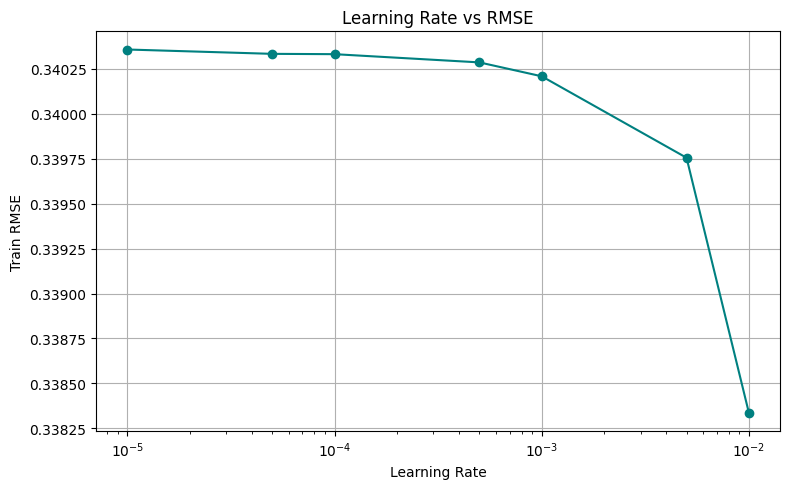

In [ ]:
mfCF_Gift_Cards_SGD.plot_learning_rate_vs_rmse()

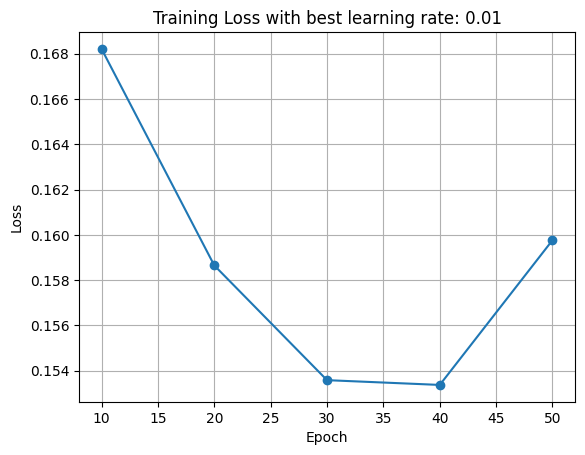

In [ ]:
mfCF_Gift_Cards_SGD.show_loss()

- Load and evaluate model

In [ ]:
mfCF_Gift_Cards_SGD = MFCFModel(
    data_path=data_path,
    folder="Gift_Cards",
    file_name="Gift_Cards",
    solver="SGD"
)

mfCF_Gift_Cards_SGD.run_loaded_evaluate(save_path)

✅ Model and parameters loaded successfully.

🔹 Loading data for: Gift_Cards
🔹 Normalizing Y (per user mean)...


🔁 Normalizing per user:   0%|          | 0/377 [00:00<?, ?it/s]


🔎 Loaded model, evaluating train and test sets...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2052 [00:00<?, ?it/s]

📊 Train RMSE: 0.3383, MAE: 0.0900

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Test RMSE: 0.4101, MAE: 0.1090

📌 Metrics saved with key prefix 'MF_Gift_Cards_SGD'


#### ALS

- First train and save model

In [ ]:
mfCF_Gift_Cards_ALS = MFCFModel(
    data_path=data_path,
    folder="Gift_Cards",
    file_name="Gift_Cards",
    solver="ALS",
    k=50,
    max_iter=50,
    learning_rate=learning_rates,
    lam=0.1,
    batch_size=512,
    print_every=10,
)

mfCF_Gift_Cards_ALS.run_train_and_save(save_path)


🔹 Loading data for: Gift_Cards
🔹 Normalizing Y (per user mean)...


🔁 Normalizing per user:   0%|          | 0/377 [00:00<?, ?it/s]


🚀 Training with learning rate: 1e-05
🔹 Training MF model using solver: ALS
   🔁 ALS Iter 10/50
   🔁 ALS Iter 20/50
   🔁 ALS Iter 30/50
   🔁 ALS Iter 40/50
   🔁 ALS Iter 50/50
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2052 [00:00<?, ?it/s]

📊 Train RMSE: 0.9887, MAE: 0.4463
📈 Learning Rate 1e-05 - Train RMSE: 0.9887

🚀 Training with learning rate: 5e-05
🔹 Training MF model using solver: ALS
   🔁 ALS Iter 10/50
   🔁 ALS Iter 20/50
   🔁 ALS Iter 30/50
   🔁 ALS Iter 40/50
   🔁 ALS Iter 50/50
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


...

📊 Train RMSE: 0.9371, MAE: 0.4073
📈 Learning Rate 0.01 - Train RMSE: 0.9371
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/MF_ALS_Gift_Cards.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2052 [00:00<?, ?it/s]

📊 Train RMSE: 0.9211, MAE: 0.4183

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Test RMSE: 0.8788, MAE: 0.4034

📌 Best learning rate: 5e-05	RMSE: 0.9211	MAE: 0.4183
📌 Metrics saved with key prefix 'MF_Gift_Cards_ALS'


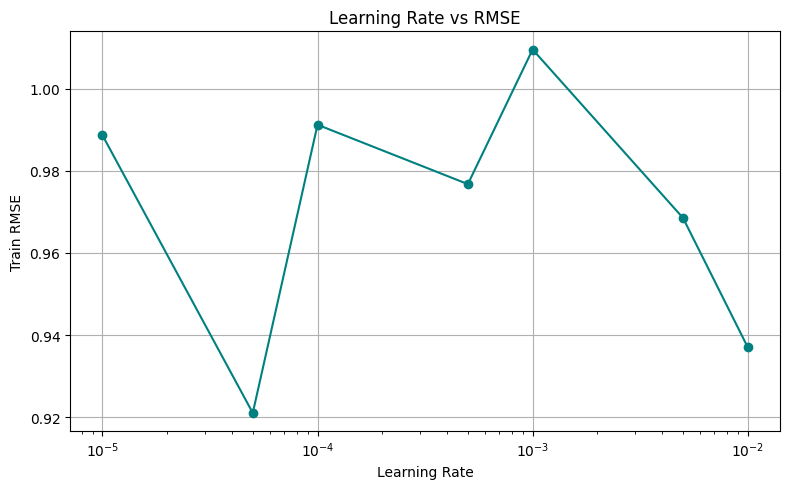

In [ ]:
mfCF_Gift_Cards_ALS.plot_learning_rate_vs_rmse()

- Load and evaluate model

In [ ]:
mfCF_Gift_Cards_ALS = MFCFModel(
    data_path=data_path,
    folder="Gift_Cards",
    file_name="Gift_Cards",
    solver="ALS"
)

mfCF_Gift_Cards_ALS.run_loaded_evaluate(save_path)

✅ Model and parameters loaded successfully.

🔹 Loading data for: Gift_Cards
🔹 Normalizing Y (per user mean)...


🔁 Normalizing per user:   0%|          | 0/377 [00:00<?, ?it/s]


🔎 Loaded model, evaluating train and test sets...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2052 [00:00<?, ?it/s]

📊 Train RMSE: 0.9211, MAE: 0.4183

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/377 [00:00<?, ?it/s]

📊 Test RMSE: 0.8788, MAE: 0.4034

📌 Metrics saved with key prefix 'MF_Gift_Cards_ALS'


###Cell_Phones_and_Accessories

####SGD

- First train and save model

In [ ]:
mfCF_Cell_Phones_and_Accessories_SGD = MFCFModel(
    data_path=data_path,
    folder="Cell_Phones_and_Accessories",
    file_name="Cell_Phones_and_Accessories",
    solver="SGD",
    k=50,
    max_iter=50,
    learning_rate=learning_rates,
    lam=0.1,
    batch_size=512,
    print_every=10,
)

mfCF_Cell_Phones_and_Accessories_SGD.run_train_and_save(save_path)


🔹 Loading data for: Cell_Phones_and_Accessories
🔹 Normalizing Y (per user mean)...


🔁 Normalizing per user:   0%|          | 0/380999 [00:00<?, ?it/s]


🚀 Training with learning rate: 1e-05
🔹 Training MF model using solver: SGD
   🔁 Iter 10/50 - Loss: 123.6162
   🔁 Iter 20/50 - Loss: 123.5927
   🔁 Iter 30/50 - Loss: 123.5690
   🔁 Iter 40/50 - Loss: 123.5456
   🔁 Iter 50/50 - Loss: 123.5222
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2371786 [00:00<?, ?it/s]

📊 Train RMSE: 1.0494, MAE: 0.7287
📈 Learning Rate 1e-05 - Train RMSE: 1.0494

🚀 Training with learning rate: 5e-05
🔹 Training MF model using solver: SGD
   🔁 Iter 10/50 - Loss: 123.5679
   🔁 Iter 20/50 - Loss: 123.4530
   🔁 Iter 30/50 - Loss: 123.3402
   🔁 Iter 40/50 - Loss: 123.2296
   🔁 Iter 50/50 - Loss: 123.1210
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


...

📊 Train RMSE: 0.8897, MAE: 0.6170
📈 Learning Rate 0.01 - Train RMSE: 0.8897
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/MF_SGD_Cell_Phones_and_Accessories.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2371786 [00:00<?, ?it/s]

📊 Train RMSE: 0.8897, MAE: 0.6170

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/380999 [00:00<?, ?it/s]

📊 Test RMSE: 1.2759, MAE: 0.8896

📌 Best learning rate: 0.01	RMSE: 0.8897	MAE: 0.6170
📌 Metrics saved with key prefix 'MF_Cell_Phones_and_Accessories_SGD'


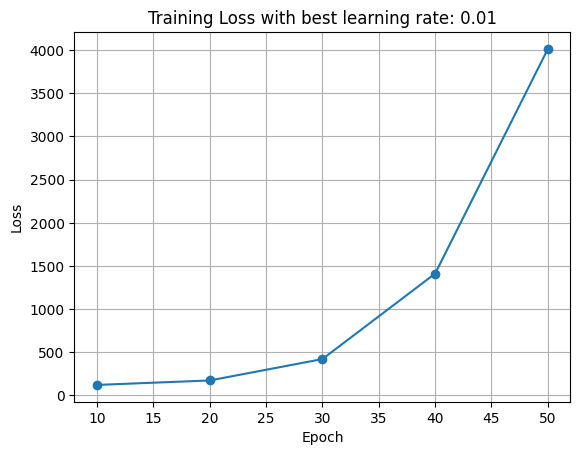

In [ ]:
mfCF_Cell_Phones_and_Accessories_SGD.show_loss()

- Load and evaluate model

In [ ]:
mfCF_Cell_Phones_and_Accessories_SGD = MFCFModel(
    data_path=data_path,
    folder="Cell_Phones_and_Accessories",
    file_name="Cell_Phones_and_Accessories",
    solver="SGD"
)

mfCF_Cell_Phones_and_Accessories_SGD.run_loaded_evaluate(save_path)

✅ Model and parameters loaded successfully.

🔹 Loading data for: Cell_Phones_and_Accessories
🔹 Normalizing Y (per user mean)...


🔁 Normalizing per user:   0%|          | 0/380999 [00:00<?, ?it/s]


🔎 Loaded model, evaluating train and test sets...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/2371786 [00:00<?, ?it/s]

📊 Train RMSE: 0.8897, MAE: 0.6170

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/380999 [00:00<?, ?it/s]

📊 Test RMSE: 1.2759, MAE: 0.8896

📌 Metrics saved with key prefix 'MF_Cell_Phones_and_Accessories_SGD'


#### ALS

- First train and save model

In [ ]:
mfCF_Cell_Phones_and_Accessories_ALS = MFCFModel(
    data_path=data_path,
    folder="Cell_Phones_and_Accessories",
    file_name="Cell_Phones_and_Accessories",
    solver="ALS",
    k=50,
    max_iter=50,
    learning_rate=learning_rates,
    lam=0.1,
    batch_size=512,
    print_every=10,
)

mfCF_Cell_Phones_and_Accessories_ALS.run_train_and_save(save_path)

- Load and evaluate model

In [ ]:
mfCF_Cell_Phones_and_Accessories_ALS = MFCFModel(
    data_path=data_path,
    folder="Cell_Phones_and_Accessories",
    file_name="Cell_Phones_and_Accessories",
    solver="ALS"
)

mfCF_Cell_Phones_and_Accessories_ALS.run_loaded_evaluate(save_path)

###Movies Len 1M

#### SGD

- First train and save model

In [ ]:
mfCF_ml1m_SGD = MFCFModel(
    data_path=data_path,
    folder="ml-1m",
    file_name="ml-1m",
    solver="SGD",
    k=50,
    max_iter=50,
    learning_rate=learning_rates,
    lam=0.1,
    batch_size=512,
    print_every=10,
)

mfCF_ml1m_SGD.run_train_and_save(save_path)


🔹 Loading data for: ml-1m
🔹 Normalizing Y (per user mean)...


🔁 Normalizing per user:   0%|          | 0/6040 [00:00<?, ?it/s]


🚀 Training with learning rate: 1e-05
🔹 Training MF model using solver: SGD
   🔁 Iter 10/50 - Loss: 2.9561
   🔁 Iter 20/50 - Loss: 2.9463
   🔁 Iter 30/50 - Loss: 2.9366
   🔁 Iter 40/50 - Loss: 2.9271
   🔁 Iter 50/50 - Loss: 2.9177
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/994169 [00:00<?, ?it/s]

📊 Train RMSE: 1.0280, MAE: 0.8230
📈 Learning Rate 1e-05 - Train RMSE: 1.0280

🚀 Training with learning rate: 5e-05
🔹 Training MF model using solver: SGD
   🔁 Iter 10/50 - Loss: 2.9152
   🔁 Iter 20/50 - Loss: 2.8703
   🔁 Iter 30/50 - Loss: 2.8283
   🔁 Iter 40/50 - Loss: 2.7887
   🔁 Iter 50/50 - Loss: 2.7513
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


...

📊 Train RMSE: 0.8552, MAE: 0.6756
📈 Learning Rate 0.01 - Train RMSE: 0.8552
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/MF_SGD_ml-1m.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/994169 [00:00<?, ?it/s]

📊 Train RMSE: 0.8552, MAE: 0.6756

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/6040 [00:00<?, ?it/s]

📊 Test RMSE: 0.9473, MAE: 0.7442

📌 Best learning rate: 0.01	RMSE: 0.8552	MAE: 0.6756
📌 Metrics saved with key prefix 'MF_ml-1m_SGD'


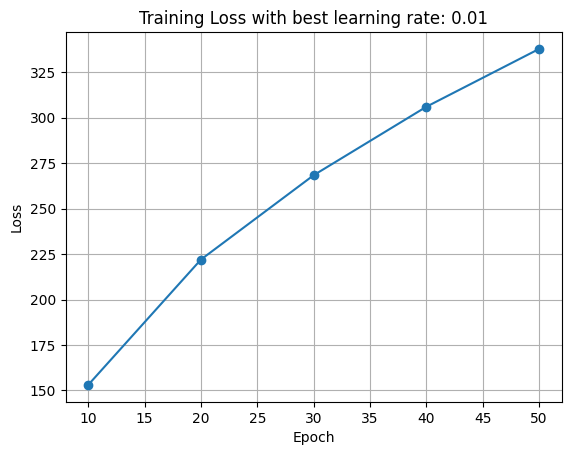

In [ ]:
mfCF_ml1m_SGD.show_loss()

- Load and evaluate model

In [ ]:
mfCF_ml1m_SGD = MFCFModel(
    data_path=data_path,
    folder="ml-1m",
    file_name="ml-1m",
    solver="SGD"
)

mfCF_ml1m_SGD.run_loaded_evaluate(save_path)

#### ALS

- First train and save model

In [ ]:
mfCF_ml1m_ALS = MFCFModel(
    data_path=data_path,
    folder="ml-1m",
    file_name="ml-1m",
    solver="ALS",
    k=50,
    max_iter=50,
    learning_rate=learning_rates,
    lam=0.1,
    batch_size=512,
    print_every=10,
)

mfCF_ml1m_ALS.run_train_and_save(save_path)


🔹 Loading data for: ml-1m
🔹 Normalizing Y (per user mean)...


🔁 Normalizing per user:   0%|          | 0/6040 [00:00<?, ?it/s]


🚀 Training with learning rate: 1e-05
🔹 Training MF model using solver: ALS
   🔁 ALS Iter 10/50
   🔁 ALS Iter 20/50
   🔁 ALS Iter 30/50
   🔁 ALS Iter 40/50
   🔁 ALS Iter 50/50
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/994169 [00:00<?, ?it/s]

📊 Train RMSE: 1.1803, MAE: 0.7714
📈 Learning Rate 1e-05 - Train RMSE: 1.1803

🚀 Training with learning rate: 5e-05
🔹 Training MF model using solver: ALS
   🔁 ALS Iter 10/50
   🔁 ALS Iter 20/50
   🔁 ALS Iter 30/50
   🔁 ALS Iter 40/50
   🔁 ALS Iter 50/50
✅ Training completed, evaluating results...

🔍 Evaluating on Train set...


...

📊 Train RMSE: 1.1812, MAE: 0.7720
📈 Learning Rate 0.01 - Train RMSE: 1.1812
📂 Model saved to /content/drive/My Drive/IU/Thesis/hybrid_recommendation_system/models/explicit/MF_ALS_ml-1m.pkl

🔍 Evaluating on Train set...


📊 Train Evaluation:   0%|          | 0/994169 [00:00<?, ?it/s]

📊 Train RMSE: 1.1803, MAE: 0.7714

🔍 Evaluating on Test set...


📊 Test Evaluation:   0%|          | 0/6040 [00:00<?, ?it/s]

📊 Test RMSE: 1.3353, MAE: 1.0122

📌 Best learning rate: 1e-05	RMSE: 1.1803	MAE: 0.7714
📌 Metrics saved with key prefix 'MF_ml-1m_ALS'


- Load and evaluate model

In [ ]:
mfCF_ml1m_ALS = MFCFModel(
    data_path=data_path,
    folder="ml-1m",
    file_name="ml-1m",
    solver="ALS"
)

mfCF_ml1m_ALS.run_loaded_evaluate(save_path)

##Evaluate

In [ ]:
for key, value in GLOBAL_METRICS.items():
    print(f"{key}: {value}")

RMSE_MF_ml-1m_ALS_Train: 1.1803150344937965
MAE_MF_ml-1m_ALS_Train: 0.7714054312706632
RMSE_MF_ml-1m_ALS_Test: 1.3352800934893254
MAE_MF_ml-1m_ALS_Test: 1.0122455585081847


In [ ]:
metrics = GLOBAL_METRICS

In [ ]:
metrics["RMSE_CBF_Cell_Phones_and_Accessories_Train"] = 0.0027115756194109387
metrics["MAE_CBF_Cell_Phones_and_Accessories_Train"] = 0.00010139449012005779
metrics["RMSE_CBF_Cell_Phones_and_Accessories_Test"] = 1.300156673741003
metrics["MAE_CBF_Cell_Phones_and_Accessories_Test"] = 0.8975134279806758

metrics["RMSE_CBF_ml-1m_Train"] = 0.5636909654220011
metrics["MAE_CBF_ml-1m_Train"] = 0.32658904797281996
metrics["RMSE_CBF_ml-1m_Test"] = 2.065163259451207
metrics["MAE_CBF_ml-1m_Test"] = 1.4258220628517233

metrics["RMSE_UUCF_Cell_Phones_and_Accessories_Train"] = 1.3849
metrics["MAE_UUCF_Cell_Phones_and_Accessories_Train"] = 0.7296
metrics["RMSE_UUCF_Cell_Phones_and_Accessories_Test"] = 1.2983
metrics["MAE_UUCF_Cell_Phones_and_Accessories_Test"] = 0.8728

metrics["RMSE_UUCF_ml-1m_Train"] = 1.7827
metrics["MAE_UUCF_ml-1m_Train"] = 1.4024
metrics["RMSE_UUCF_ml-1m_Test"] = 1.7769
metrics["MAE_UUCF_ml-1m_Test"] = 1.3603

metrics["RMSE_IICF_Cell_Phones_and_Accessories_Train"] = 0.8244
metrics["MAE_IICF_Cell_Phones_and_Accessories_Train"] = 0.5314
metrics["RMSE_IICF_Cell_Phones_and_Accessories_Test"] = 1.2868
metrics["MAE_IICF_Cell_Phones_and_Accessories_Test"] = 0.9613

metrics["RMSE_IICF_ml-1m_Train"] = 0.7816
metrics["MAE_IICF_ml-1m_Train"] = 0.6077
metrics["RMSE_IICF_ml-1m_Test"] = 0.9419
metrics["MAE_IICF_ml-1m_Test"] = 0.7261

metrics["RMSE_MF_Cell_Phones_and_Accessories_SGD_Train"] = 0.8897
metrics["MAE_MF_Cell_Phones_and_Accessories_SGD_Train"] = 0.617
metrics["RMSE_MF_Cell_Phones_and_Accessories_SGD_Test"] = 1.2759
metrics["MAE_MF_Cell_Phones_and_Accessories_SGD_Test"] = 0.8896

metrics["RMSE_MF_Cell_Phones_and_Accessories_ALS_Train"] = 0.7988
metrics["MAE_MF_Cell_Phones_and_Accessories_ALS_Train"] = 0.716
metrics["RMSE_MF_Cell_Phones_and_Accessories_ALS_Test"] = 1.5279
metrics["MAE_MF_Cell_Phones_and_Accessories_ALS_Test"] = 0.9886

metrics["RMSE_MF_ml-1m_SGD_Train"] = 0.8552
metrics["MAE_MF_ml-1m_SGD_Train"] = 0.6756
metrics["RMSE_MF_ml-1m_SGD_Test"] = 0.9473
metrics["MAE_MF_ml-1m_SGD_Test"] = 0.7442

metrics["RMSE_MF_ml-1m_ALS_Train"] = 1.1803150344937965
metrics["MAE_MF_ml-1m_ALS_Train"] = 0.7714054312706632
metrics["RMSE_MF_ml-1m_ALS_Test"] = 1.3352800934893254
metrics["MAE_MF_ml-1m_ALS_Test"] = 1.0122455585081847

In [ ]:
data_list = []
for key, value in metrics.items():
    parts = key.split('_')
    metric = parts[0]  # RMSE hoặc MAE
    model = parts[1]   # CBF, uuCF, iiCF, MF

    # Check nếu mô hình là MF và có hậu tố như SGD, ALS
    if model == 'MF' and parts[-2] in ['SGD', 'ALS']:
        variant = parts[-2]
        model_name = f"MF ({variant})"
        dataset = '_'.join(parts[2:-2])  # Loại bỏ cả variant và Train/Test
    else:
        model_name = model
        dataset = '_'.join(parts[2:-1])  # Bình thường loại bỏ phần Train/Test

    dataset_type = parts[-1]  # Train/Test

    data_list.append({
        'Metric': metric,
        'Model': model_name,
        'Dataset': dataset,
        'Type': dataset_type,
        'Value': value
    })

df = pd.DataFrame(data_list)
print(df)

   Metric     Model                      Dataset   Type     Value
0    RMSE       CBF  Cell_Phones_and_Accessories  Train  0.002712
1     MAE       CBF  Cell_Phones_and_Accessories  Train  0.000101
2    RMSE       CBF  Cell_Phones_and_Accessories   Test  1.300157
3     MAE       CBF  Cell_Phones_and_Accessories   Test  0.897513
4    RMSE       CBF                        ml-1m  Train  0.563691
5     MAE       CBF                        ml-1m  Train  0.326589
6    RMSE       CBF                        ml-1m   Test  2.065163
7     MAE       CBF                        ml-1m   Test  1.425822
8    RMSE      UUCF  Cell_Phones_and_Accessories  Train  1.384900
9     MAE      UUCF  Cell_Phones_and_Accessories  Train  0.729600
10   RMSE      UUCF  Cell_Phones_and_Accessories   Test  1.298300
11    MAE      UUCF  Cell_Phones_and_Accessories   Test  0.872800
12   RMSE      UUCF                        ml-1m  Train  1.782700
13    MAE      UUCF                        ml-1m  Train  1.402400
14   RMSE 

###RMSE

<ipython-input-21-3709845854>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=filtered_df, x='Dataset', y='Value', hue='Model', ci=None)


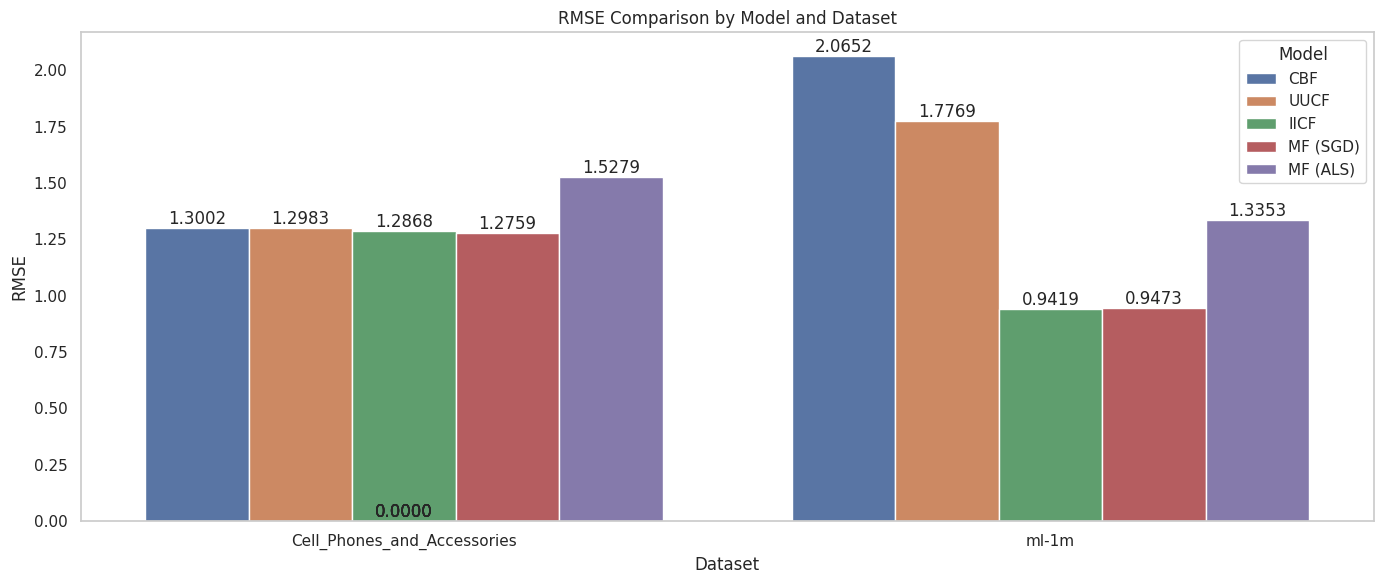

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả sử bạn vẫn sử dụng df như bạn đang có:
# df = pd.DataFrame(data_list)

# Lọc dữ kiện chỉ RMSE-Test
filtered_df = df[(df['Metric'] == 'RMSE') & (df['Type'] == 'Test')]

# Vẽ barplot
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=filtered_df, x='Dataset', y='Value', hue='Model', ci=None)
ax.set_title('RMSE Comparison by Model and Dataset')
ax.set_ylabel('RMSE')
ax.legend(title='Model')
ax.grid(axis='y')
# Hiển thị số lên mỗi thanh
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.4f}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom')
plt.xticks()
plt.tight_layout()
plt.show()

<ipython-input-20-3456876218>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df[df['Metric'] == 'RMSE'], x='Dataset', y='Value', hue='Model', ci=None)


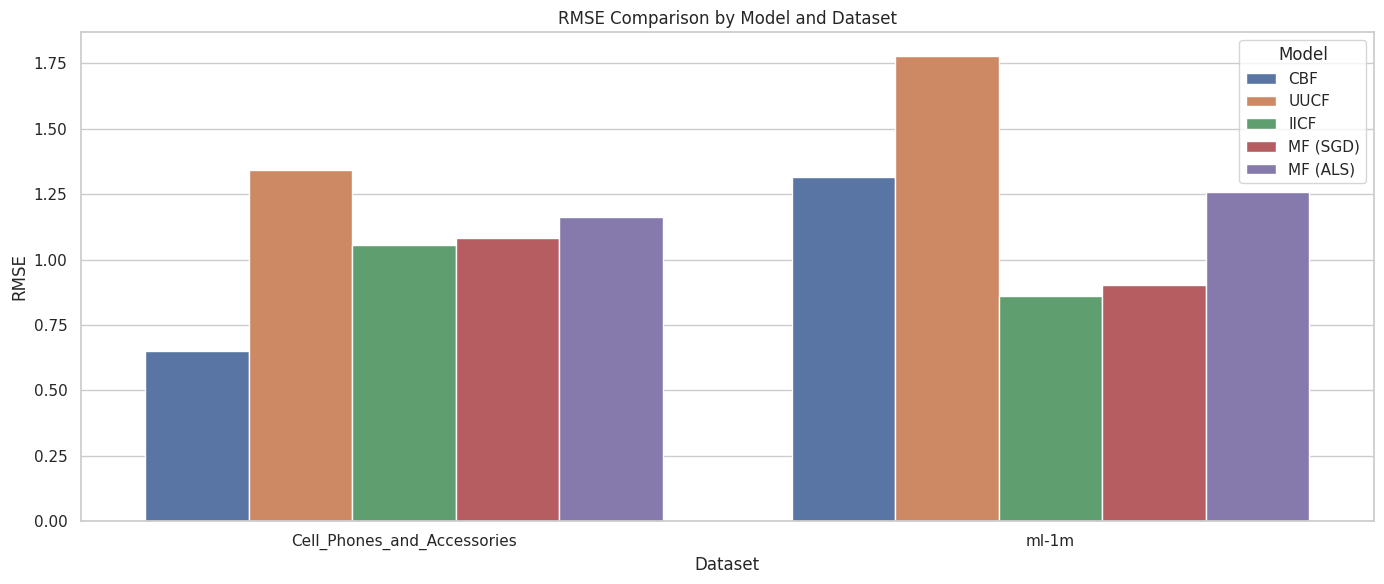

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(14, 6))
sns.barplot(data=df[df['Metric'] == 'RMSE'], x='Dataset', y='Value', hue='Model', ci=None)
plt.title('RMSE Comparison by Model and Dataset')
plt.ylabel('RMSE')
plt.xticks()
plt.legend(title='Model')
plt.tight_layout()
plt.show()

###MAE

<ipython-input-14-1126898226>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df[df['Metric'] == 'MAE'], x='Dataset', y='Value', hue='Model', ci=None)


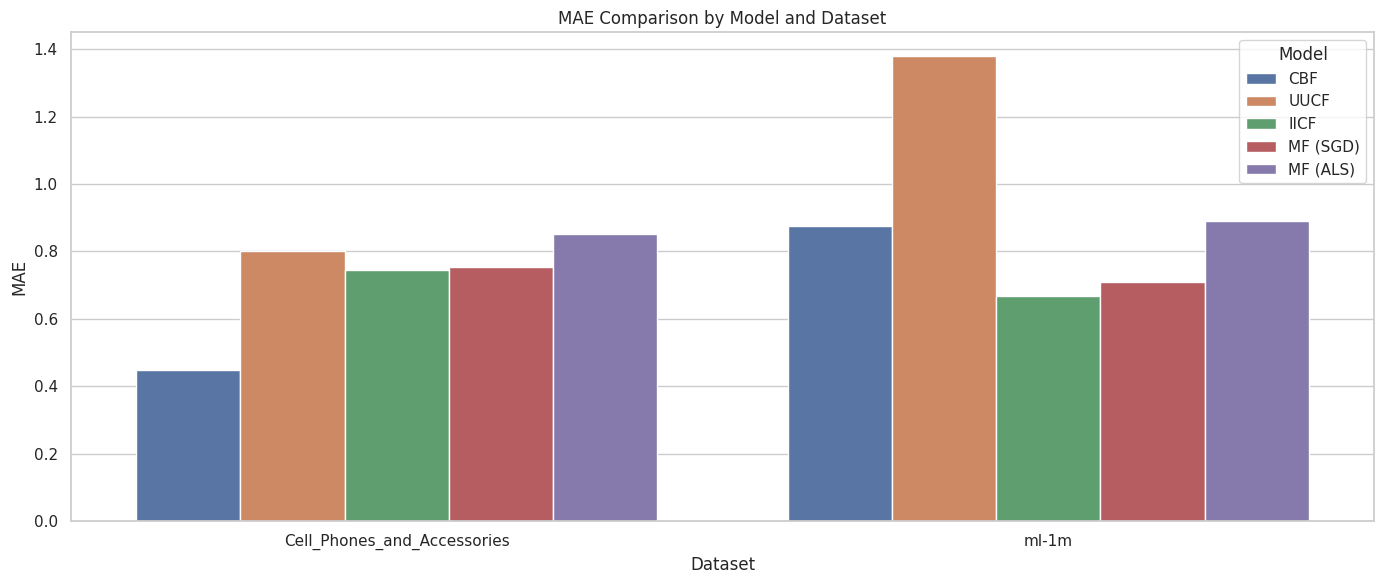

In [ ]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df[df['Metric'] == 'MAE'], x='Dataset', y='Value', hue='Model', ci=None)
plt.title('MAE Comparison by Model and Dataset')
plt.ylabel('MAE')
plt.xticks()
plt.legend(title='Model')
plt.tight_layout()
plt.show()